# Knowledge Distillation

Train a large **teacher** to convergence, then use its soft probability outputs to supervise a much smaller **student** — transferring generalisation without the full parameter cost.

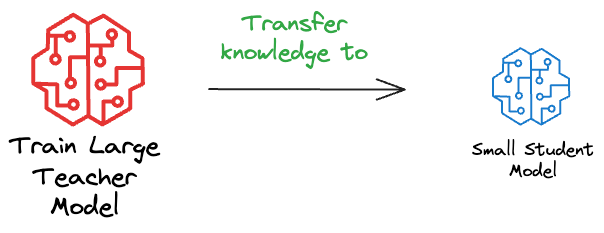

In [1]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F
from torchvision import datasets, transforms 
import random , numpy as np 
from torch.utils.data import DataLoader 


In [2]:
# -----------------------------
# Setup
# -----------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda")
USE_AMP = torch.cuda.is_available()  # enable mixed precision on GPU

import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.10.0+cu128
12.8
True


## Models

| | Architecture | Params |
|---|---|---|
| **Teacher** | Conv → Conv → FC(128) → FC(10) | ~1.2 M |
| **Student** | FC(20) → FC(10) | ~16 K |

Student is 75× smaller — trained from scratch it would underfit; distillation bridges the gap. 

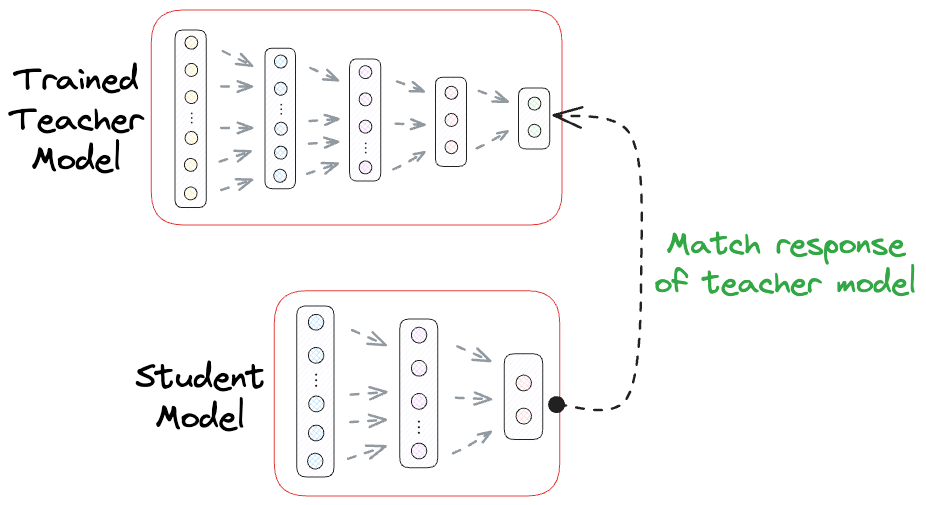

In [3]:
# -----------------------------
# Models
# -----------------------------
class TeacherNet(nn.Module):
    """Simple CNN teacher."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)  # 64*12*12 after convs + maxpool(2)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class StudentNet(nn.Module):
    """Smaller MLP student"""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 20)   # fewer hidden neurons
        self.fc2 = nn.Linear(20, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [4]:
# -----------------------------
# Data
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # standard MNIST normalization
])

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 406kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.78MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]


In [5]:
# -----------------------------
# Helpers
# -----------------------------
@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        logits = model(x)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return 100.0 * correct / max(1, total)


In [6]:
# -----------------------------
# Train Teacher (quick demo)
# -----------------------------
teacher = TeacherNet().to(DEVICE)
t_opt = torch.optim.Adam(teacher.parameters(), lr=1e-3)

print("Training teacher for 3 epoch (demo)…")
teacher.train()
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
for epoch in range(3):
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        t_opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = teacher(x)
            loss = F.cross_entropy(logits, y)
        scaler.scale(loss).backward()
        scaler.step(t_opt)
        scaler.update()
        running += loss.item()
    print(f"Teacher epoch {epoch+1} | loss {running/len(train_loader):.4f}")

teacher_acc = accuracy(teacher, test_loader)
print(f"Teacher test accuracy: {teacher_acc:.2f}%")

Training teacher for 3 epoch (demo)…
Teacher epoch 1 | loss 0.1496
Teacher epoch 2 | loss 0.0408
Teacher epoch 3 | loss 0.0243
Teacher test accuracy: 98.73%


In [7]:
teacher.eval() 
for p in teacher.parameters():
    p.requires_grad_(False)


## Distillation

Loss combines hard labels and soft teacher targets:

```
L = α · CE(student_logits, labels) + (1 − α) · KL(student/T ∥ teacher/T) · T²
```

- **T (temperature)** — softens the teacher's distribution; higher T reveals more inter-class structure.  
- **α** — balances ground-truth supervision vs. teacher guidance.

# About the KL divergence term: 

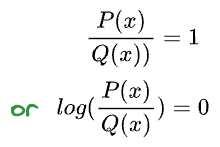  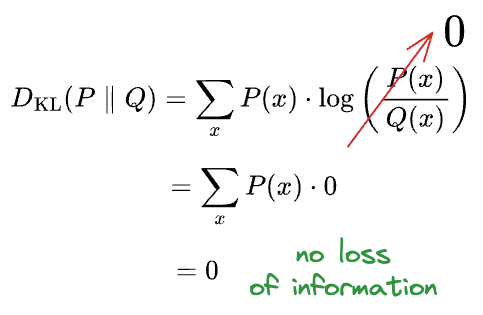

In [15]:
# -----------------------------
# Train Student with KD
# -----------------------------
student_kd = StudentNet().to(DEVICE)
opt_kd = torch.optim.Adam(student_kd.parameters(), lr=1e-3)

T = 5.0         # temperature
ALPHA = 0.5     # weight on hard-label CE; (1-ALPHA) on KD
EPOCHS_STUDENT = 3

In [16]:
print("\nTraining student with knowledge distillation…")
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
for epoch in range(EPOCHS_STUDENT):
    student_kd.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

        with torch.no_grad():
            t_logits = teacher(x)
            t_probs  = F.softmax(t_logits / T, dim=1)

        opt_kd.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            s_logits = student_kd(x)
            s_log_probs = F.log_softmax(s_logits / T, dim=1)

            kd_loss = F.kl_div(s_log_probs, t_probs, reduction="batchmean") * (T * T)
            ce_loss = F.cross_entropy(s_logits, y)
            loss = ALPHA * ce_loss + (1 - ALPHA) * kd_loss

        scaler.scale(loss).backward()
        scaler.step(opt_kd)
        scaler.update()
        running += loss.item()

    acc = accuracy(student_kd, test_loader)
    print(f"Student-KD epoch {epoch+1}/{EPOCHS_STUDENT} | loss {running/len(train_loader):.4f} | test acc {acc:.2f}%")



Training student with knowledge distillation…
Student-KD epoch 1/3 | loss 4.3512 | test acc 89.98%
Student-KD epoch 2/3 | loss 2.1457 | test acc 92.05%
Student-KD epoch 3/3 | loss 1.7205 | test acc 93.32%


## Results

Parameter count and accuracy vs. teacher — distillation recovers most accuracy at a fraction of the cost.

In [17]:
# -----------------------------
# Summary
# -----------------------------
print("\n=== Results Summary ===")
print(f"Teacher test acc:       {accuracy(teacher, test_loader):.2f}%")
print(f"Student (KD) test acc:  {accuracy(student_kd, test_loader):.2f}%")

tp = sum(p.numel() for p in teacher.parameters())
sp = sum(p.numel() for p in student_kd.parameters())
print(f"\nParams — Teacher: {tp:,} | Student: {sp:,} | Compression: {tp/sp:.1f}x")


=== Results Summary ===
Teacher test acc:       98.73%
Student (KD) test acc:  93.32%

Params — Teacher: 1,199,882 | Student: 15,910 | Compression: 75.4x


In [18]:
%timeit accuracy(teacher, test_loader)

2 s ± 345 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [19]:
%timeit accuracy(student_kd, test_loader)

1.96 s ± 285 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
